## Computational Homework 1, 2026

#### Due September 9

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *
from scipy.constants import g
from matplotlib.text import Annotation
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D

# Pretty print of differential equation solutions
init_printing(use_latex='mathjax')

# Make readable plots
plt.rcParams.update({'font.size':16, 'axes.labelsize':16})

Unless expressly stated otherwise, please make sure your plot axes have labels and multiple lines on the same plot are explained in a legend.

#### Brachistochrone problem

Here you will make a two-panel figure showing position and velocity along the cycloid curve discussed in Chapter 6, Example 2 of your textbook. The cycloid is the solution to the brachistochrone problem.

<ol>
    <li>In the top panel of your figure, plot one downward loop of the cycloid. Put one end of the curve at the origin of your coordinate system. Mark both axes in units of $a$, the radius of the wheel that would create your cycloid if rolled on the underside of the $x$-axis.</li>
    <li>Assume a small, frictionless block slides down the cycloid starting at rest from the origin. In your figure's bottom panel, plot the velocity of the block as a function of the $x$-coordinate. Make sure both plots share the same $x$-axis.</li>
</ol>

In [2]:
# Parametric equations for cycloid (theta in radians)
def upside_down_cycloid(theta, a):
    x = a*(theta - np.sin(theta))
    y = -a*(1 - np.cos(theta))
    return x, y

# Array of theta values
thetas = np.linspace(0, 2*np.pi, num=200)

In [3]:
# Speed function
speed = lambda y: np.sqrt(2*g * -y)

In [4]:
# Calculate (x, y) coordinates and speeds
xc, yc = upside_down_cycloid(thetas, 1)
speedc = speed(yc)

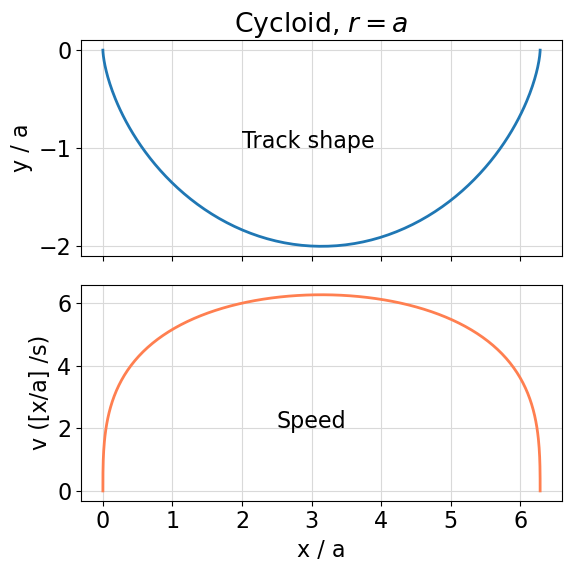

In [5]:
# Make plot
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6,6))

ax1.plot(xc, yc, lw=2)
ax1.set_ylabel('y / a')
ax1.set_title(r"Cycloid, $r = a$")
ax1.grid(color='0.85')
ax1.text(2, -1, 'Track shape')

ax2.plot(xc, speedc, lw=2, color='coral')
ax2.set_xlabel('x / a')
ax2.set_ylabel('v ([x/a] /s)')
ax2.grid(color='0.85')
ax2.text(2.5, 2, 'Speed')

fig.tight_layout()

#### Symbolic math with [<tt>SymPy</tt>](https://docs.sympy.org/latest/index.html)

<ol start=3>
    <li>Use <tt>SymPy</tt> to find the path $y(x)$ for which the integral 
    $\int_{x_1}^{x^2} x \sqrt{1 - y^{\prime}(x)^2} \: dx$ is stationary.</li>
</ol>



In [6]:
# Define constant, function, derivative, and functional
C = symbols('C', real = True, constant = True)
x = symbols('x')
y = Function('y')
yp = y(x).diff(x)

In [7]:
# Specify Euler-Lagrange equation in 1st integral form
EL = Eq(x * yp / (1-yp**2)**(1/2), C)

In [8]:
# Make computer print type(s) of ODE - solver will try algorithm for first type
classify_ode(EL, y(x))

('factorable', 'nth_algebraic', 'lie_group', 'nth_algebraic_Integral')

In [9]:
# Solve
dsolve(EL, y(x))

⎡           ⌠                                  ⌠                       ⎤
⎢           ⎮      _________                   ⎮      _________        ⎥
⎢           ⎮     ╱    1                       ⎮     ╱    1            ⎥
⎢y(x) = - C⋅⎮    ╱  ───────  dx + C₁, y(x) = C⋅⎮    ╱  ───────  dx + C₁⎥
⎢           ⎮   ╱    2    2                    ⎮   ╱    2    2         ⎥
⎢           ⎮ ╲╱    C  + x                     ⎮ ╲╱    C  + x          ⎥
⎣           ⌡                                  ⌡                       ⎦

In [10]:
# Define arcsinh function and print derivative
asinh = functions.elementary.hyperbolic.asinh(x)
asinh.diff(x)

     1     
───────────
   ________
  ╱  2     
╲╱  x  + 1 

#### Learning to figure skate

Olympic figure skaters used to be judged on how well they could carve attractive shapes into the ice. Coaches of novice skaters would etch guide circles into the ice using a special compass, which consisted of a horizontal rod with a pivot at one end and a sharp point attached to the underside of the rod near the other end. (Note: The ice compass is similar to the rotating rod described in Taylor problem 7.21, except the pivot is at the end of the rod instead of the center.)

<ol start=4</ol>
<li>Assume a bead slides freely along the rod with negligible friction. Place the pivot at the origin and let $r(t)$ represent the bead's distance from the pivot. Plot $r(t)$ for a bead that is near the origin at $t = 0$, when the rod starts to rotate with constant angular speed $\omega$.</li>
</ol>

#### Solution:

#### $\mathcal{L} = \frac{1}{2} m \left( \dot{r}^2 + r^2 \omega^2 \right)$

#### Euler-Lagrange equation for $r$ coordinate is $\frac{\partial \mathcal{L}}{\partial r} - \frac{d}{dt} \left( \frac{\partial \mathcal{L}}{\partial \dot{r}} \right) = 0$

#### Reduces to $\ddot{r} = r \omega^2$, with general solution $r(t) = A e^{\omega t} + B e^{-\omega t}$. For $r(t=0) = r_0$, $A + B = r_0$ and $A = B = r_0 / 2$, giving $r(t) = r_0 \cosh (\omega t)$.

#### As $t \rightarrow \infty$, $e^{\omega t} \gg e^{-\omega t}$, so $r(t) \approx \frac{1}{2} r_0 e^{\omega t}$. 

In [11]:
# Length of rod will be R, bead will start at 0.01R
R = 2
r0 = 0.01 * R
omega = 1

tt = np.linspace(0, 5, num=201, endpoint=True)
r = lambda t: r0 * np.cosh(omega*t)

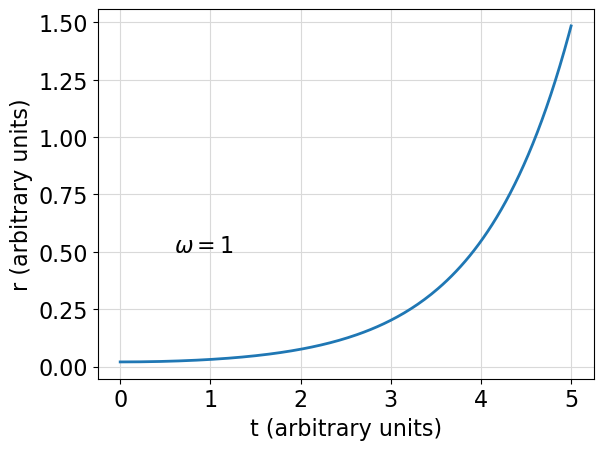

In [12]:
plt.plot(tt, r(tt), lw=2)
plt.xlabel('t (arbitrary units)')
plt.ylabel('r (arbitrary units)')
plt.text(0.6, 0.5, r"$\omega = 1$")
plt.grid(color='0.85')

#### Helical wire

A smooth wire is bent into the shape of a helix, with cylindrical polar coordinates $\rho = R$ and $z = \lambda \phi$, where $R$ and $\lambda$ are constants and the $z$ axis is oriented vertically upward. Gravity points in the $-z$ direction. (This setup is similar to the children's toy with beads on bent wires described in class.)

<ol start=5>
    <li>Use <tt>matplotlib</tt> to draw a cartoon representing the shape and orientation of the wire. Put $(\hat{x}, \hat{z})$ unit vectors on your cartoon. You may turn of the plot axes if you wish.</li>
    <li>Plot the bead's acceleration in the vertical direction, $\ddot{z}(z)$.</li>
</ol>

Solution to problem 5:

In [13]:
# In this equation for a helix, rho = R = 1 implicitly
def helix(lam, phi):
    x = np.cos(phi)
    y = np.sin(phi)
    z = lam * phi
    return x, y, z

In [14]:
phis = np.linspace(0, 8*np.pi, num=200)
lam = 2
xc, yc, zc = helix(lam, phis)

In [15]:
# Class and function for drawing arrows in 3d
# From https://gist.github.com/WetHat/1d6cd0f7309535311a539b42cccca89c

class Annotation3D(Annotation):

    def __init__(self, text, xyz, *args, **kwargs):
        super().__init__(text, xy=(0, 0), *args, **kwargs)
        self._xyz = xyz

    def draw(self, renderer):
        x2, y2, z2 = proj_transform(*self._xyz, self.axes.M)
        self.xy = (x2, y2)
        super().draw(renderer)

def _annotate3D(ax, text, xyz, *args, **kwargs):
    '''Add anotation `text` to an `Axes3d` instance.'''

    annotation = Annotation3D(text, xyz, *args, **kwargs)
    ax.add_artist(annotation)

setattr(Axes3D, 'annotate3D', _annotate3D)

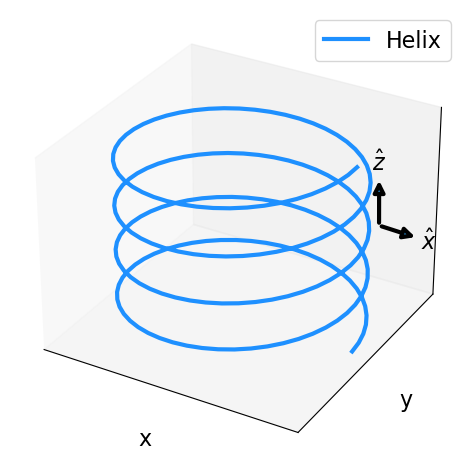

In [16]:
# Make axes
ax = plt.figure(figsize=(5,6)).add_subplot(projection='3d')

# Plot helix
ax.plot(xc, yc, zc, color='dodgerblue', lw=3, label='Helix')

# Arrows
ax.annotate3D(r"$\hat{z}$", (0.78, 0.85, 20),
              xytext=(-5, 40),
              textcoords='offset points',
              arrowprops=dict(arrowstyle="<|-", ec='black', lw=3))

ax.annotate3D(r"$\hat{x}$", (0.78, 0.85, 20),
              xytext=(30, -17),
              textcoords='offset points',
              arrowprops=dict(arrowstyle="<|-", ec='black', lw=3))

# Axes
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.legend(loc='best')

# Tight layout
plt.tight_layout()

Solution to problem 6

#### $T = \frac{1}{2} m v^2 = \frac{1}{2} m \dot{z}^2 (1 + \frac{R^2}{\lambda^2})$

#### $U = mgz$

#### Euler-Lagrange equation is $\frac{\partial \mathcal{L}}{\partial z} - \frac{d}{dt} \left( \frac{\partial \mathcal{L}}{\partial \dot{z}} \right) = 0$, which simplifies to

#### $\ddot{z} = \frac{-g}{1 + R^2/\lambda^2}$

...which means $\ddot{z}$ is a constant!!

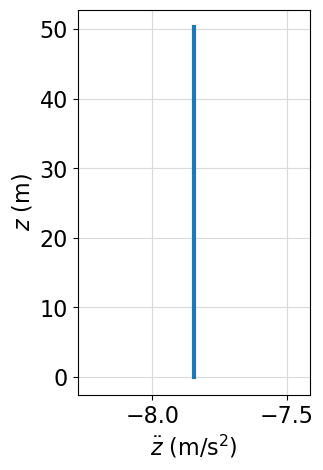

In [17]:
# I used rho = R = 1 and lambda = 2, assume mks units to match g
zdotdot = -g / 1.25

plt.figure(figsize=(3,5))
plt.plot(zdotdot * np.ones(200), zc, lw=3)
plt.xlabel(r"$\ddot{z}$ (m/s$^2$)")
plt.ylabel(r"$z$ (m)")
plt.grid(color='0.85')